In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:,2:]
y = iris.target

print(X.shape)
print(y.shape)

(150, 2)
(150,)


In [3]:
tree_clf = DecisionTreeClassifier(max_depth=3)
tree_clf.fit(X,y)

DecisionTreeClassifier(max_depth=3)

In [8]:
y_pred = tree_clf.predict(X)
from sklearn.metrics import accuracy_score
print("Acuracy score", accuracy_score(y_pred,y))

Acuracy score 0.9733333333333334


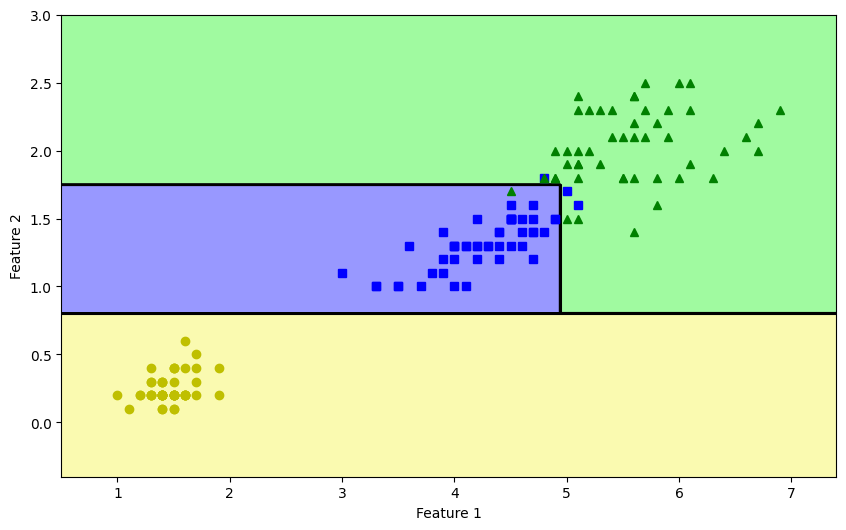

In [11]:
from matplotlib.colors import ListedColormap

def plot_boundries_dec_tree_class(model, x, y):
    x0_min, x0_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
    x1_min, x1_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

    xx0, xx1 = np.meshgrid(
        np.linspace(x0_min, x0_max, 500),
        np.linspace(x1_min, x1_max, 500)
    )

    y_pred = model.predict(np.c_[xx0.ravel(), xx1.ravel()]).reshape(xx0.shape)

    custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.contourf(xx0, xx1, y_pred, cmap=custom_cmap)
    ax.contour(xx0, xx1, y_pred, colors="black", linewidths=1.5)

    ax.plot(x[:, 0][y==0], x[:, 1][y==0], "yo", markersize=6)
    ax.plot(x[:, 0][y==1], x[:, 1][y==1], "bs", markersize=6)
    ax.plot(x[:, 0][y==2], x[:, 1][y==2], "g^", markersize=6)

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_xlim(x0_min, x0_max)
    ax.set_ylim(x1_min, x1_max)

plot_boundries_dec_tree_class(tree_clf,X,y)

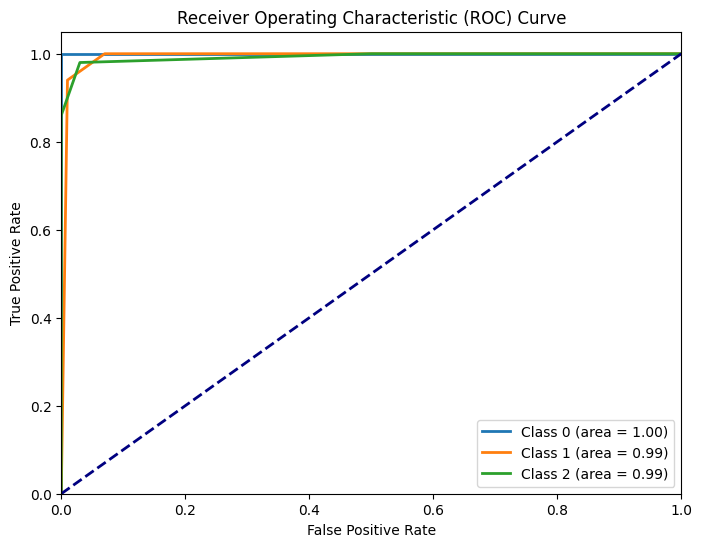

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_auc_curve(model, x, y):
    classes = np.unique(y)
    n_classes = len(classes)

    fig, ax = plt.subplots(figsize=(8, 6))

    if n_classes == 2:
        y_proba = model.predict_proba(x)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    else:
        y_bin = label_binarize(y, classes=classes)
        y_proba = model.predict_proba(x)

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f"Class {classes[i]} (area = {roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Receiver Operating Characteristic (ROC) Curve")
    ax.legend(loc="lower right")

    plt.show()

plot_roc_auc_curve(tree_clf, X, y)
